# Тест сегментации + полигоны

Загрузка чекпоинта, инференс, **адаптивный порог** (чтобы не заливало всё изображение), полигоны.

In [1]:
%load_ext autoreload
%autoreload 2

import json
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch

ROOT = Path.cwd().resolve()
if not (ROOT / 'field_detecter').is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from field_detecter.config_loader import load_config
from field_detecter.agvision_dataset import AgVisionDataset, load_agvision_tile, discover_split_root
from field_detecter.seg_infer import (
    load_segformer_checkpoint,
    load_rgb_nir,
    predict_prob,
    predict_field_mask,
    predict_mask_sliding,
    crop_mask_from_letterbox,
    prob_to_mask,
)
from field_detecter.polygon import mask_to_navigable_polygon, mask_to_polygons, polygon_to_geojson_feature
from field_detecter.metrics import binary_mask_iou, precision_recall

cfg = load_config(ROOT / 'config' / 'agvision.yaml')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CKPT = ROOT / cfg['segmentation']['output_dir'] / 'best_iou.pth'
THRESHOLD = cfg['segmentation'].get('val_threshold', 0.5)
TILE = cfg['data'].get('tile_size', 512)
# для своих снимков — выше порог и ограничение площади маски
CUSTOM_THRESHOLD = 0.75
MAX_AREA_FRAC = 0.55
LETTERBOX_META = None


## 1. Модель

In [2]:
assert CKPT.exists(), f'Нет чекпоинта: {CKPT}'
model, meta = load_segformer_checkpoint(CKPT, device=device)
print('Epoch:', meta.get('epoch'), 'val:', meta.get('val_metrics'))


Loading weights:   0%|          | 0/930 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b4-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([2])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([2, 768, 1, 1])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Epoch: 12 val: {'iou_mean': 0.9461152559973611, 'precision_mean': 0.9513153409510501, 'recall_mean': 0.9928616511294276, 'n_samples': 1000}


## 2. Тайл Ag-Vision (с GT)

IoU=0.9181  threshold=0.50  area=79.32%


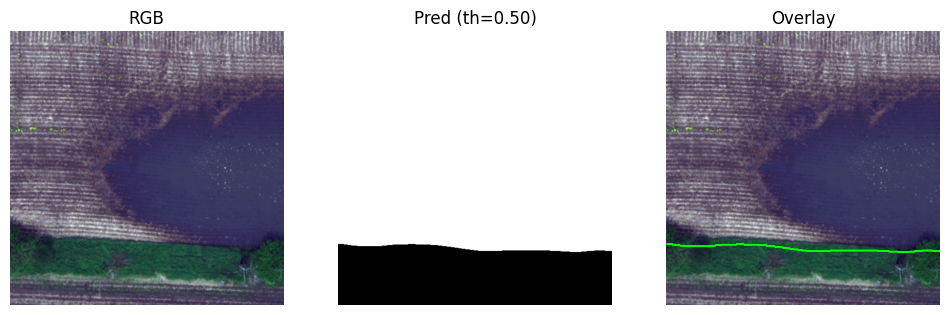

In [3]:
DATA_ROOT = ROOT / cfg['data']['root']
split_root = discover_split_root(DATA_ROOT, cfg['data']['version_dir'], 'val')
ds = AgVisionDataset(DATA_ROOT, 'val', version_dir=cfg['data']['version_dir'], max_samples=1)
sample = load_agvision_tile(split_root, ds.stems[0], tile_size=TILE)
prob = predict_prob(model, sample['image'], device, tta=True)
pred, th, info = prob_to_mask(
    prob, THRESHOLD, max_area_frac=0.95, auto_raise_threshold=False)
gt = sample['boundary']
print(f"IoU={binary_mask_iou(pred, gt):.4f}  threshold={th:.2f}  area={info['area_frac']:.2%}")

rgb = np.stack([sample['image'][1], sample['image'][2], sample['image'][3]], axis=-1)
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(rgb); ax[0].set_title('RGB')
ax[1].imshow(pred, cmap='gray'); ax[1].set_title(f'Pred (th={th:.2f})')
ax[2].imshow(rgb); ax[2].contour(pred, colors='lime', linewidths=0.8); ax[2].set_title('Overlay')
for a in ax: a.axis('off')
plt.show()


## 3. Свой снимок

**Letterbox** (без растягивания) + **адаптивный порог** + только **крупнейший** контур поля.

In [4]:
RGB_PATH = ROOT / 'data' / 'uploads' / 'inference_input.png'
if not RGB_PATH.exists():
    RGB_PATH = ROOT / 'data' / 'uploads' / 'test.png'
NIR_PATH = None
USE_SLIDING = False

assert RGB_PATH.exists(), f'Положите файл: {RGB_PATH}'

rgb, image_4ch, LETTERBOX_META = load_rgb_nir(
    RGB_PATH, NIR_PATH, tile_size=TILE, letterbox=True)

if USE_SLIDING:
    mask_lb = predict_mask_sliding(model, image_4ch, device, tile=TILE, stride=TILE//2,
                                   threshold=CUSTOM_THRESHOLD, tta=True)
    prob = predict_prob(model, image_4ch, device, tta=False)
    from field_detecter.seg_infer import prob_to_mask
    mask_lb, th, info = prob_to_mask(mask_lb.astype(np.float32), 0.5, max_area_frac=MAX_AREA_FRAC)
else:
    prob, mask_lb, th, info = predict_field_mask(
        model, image_4ch, device,
        threshold=CUSTOM_THRESHOLD,
        tta=True,
        rgb_uint8=rgb,
        max_area_frac=MAX_AREA_FRAC,
        auto_raise_threshold=True,
        keep_largest=True,
    )

if LETTERBOX_META:
    mask = crop_mask_from_letterbox(mask_lb, LETTERBOX_META)
    score_vis = info.get('score_map', crop_mask_from_letterbox(prob, LETTERBOX_META))
    prob_vis = crop_mask_from_letterbox(prob, LETTERBOX_META)
    rgb_vis = cv2.cvtColor(cv2.imread(str(RGB_PATH)), cv2.COLOR_BGR2RGB)
else:
    mask, score_vis, prob_vis, rgb_vis = mask_lb, info.get('score_map', prob), prob, rgb

print('Порог:', th, info)
if info.get('mode') == 'saturated_fallback':
    print('ℹ Сеть дала prob≈1 везде — маска построена по ExG+границам (не только по NN)')
print(f"Доля поля: {mask.mean():.2%}")
if mask.mean() > 0.7:
    print('⚠ Маска >70% кадра — увеличьте CUSTOM_THRESHOLD или уменьшите MAX_AREA_FRAC')


Порог: 0.6608366905564983 {'threshold_used': 0.6608366905564983, 'area_frac': 0.5482711791992188, 'prob_mean': 0.9657465219497681, 'prob_std': 0.041433438658714294, 'prob_max': 0.9927630424499512, 'mode': 'saturated_fallback', 'score_map': array([[0.31032348, 0.31055309, 0.3109727 , ..., 0.44682111, 0.44814199,
        0.44784944],
       [0.31070144, 0.31161641, 0.31203619, ..., 0.45254506, 0.45204774,
        0.45175245],
       [0.31430025, 0.3145312 , 0.3149504 , ..., 0.45480465, 0.45702915,
        0.45582404],
       ...,
       [0.88039416, 0.88077315, 0.88115139, ..., 0.88115139, 0.88077315,
        0.88039416],
       [0.88001741, 0.88039565, 0.88077315, ..., 0.88077315, 0.88039565,
        0.88001741],
       [0.87963991, 0.88001741, 0.88039416, ..., 0.88039416, 0.88001741,
        0.87963991]], shape=(512, 512))}
ℹ Сеть дала prob≈1 везде — маска построена по ExG+границам (не только по NN)
Доля поля: 44.77%


In [5]:
try:
    import ipywidgets as widgets
    from IPython.display import display
    from field_detecter.upload import save_first_upload
    upload = widgets.FileUpload(accept='.png,.jpg,.jpeg', multiple=False)
    display(upload)
except ImportError:
    print('ipywidgets не установлен')


FileUpload(value=(), accept='.png,.jpg,.jpeg', description='Upload')

In [6]:
dest = ROOT / 'data' / 'uploads' / 'inference_input.png'
saved = save_first_upload(upload.value, dest)
if saved:
    rgb, image_4ch, LETTERBOX_META = load_rgb_nir(saved, None, tile_size=TILE, letterbox=True)
    prob, mask_lb, th, info = predict_field_mask(
        model, image_4ch, device, threshold=CUSTOM_THRESHOLD, tta=True,
        rgb_uint8=rgb, max_area_frac=MAX_AREA_FRAC, auto_raise_threshold=True)
    mask = crop_mask_from_letterbox(mask_lb, LETTERBOX_META)
    score_vis = info.get('score_map')
    prob_vis = crop_mask_from_letterbox(prob, LETTERBOX_META)
    rgb_vis = cv2.cvtColor(cv2.imread(str(saved)), cv2.COLOR_BGR2RGB)
    print('OK', saved, info)


OK /home/eq/techlb/field_detecter/data/uploads/inference_input.png {'threshold_used': 0.6608366905564983, 'area_frac': 0.5482711791992188, 'prob_mean': 0.9657465219497681, 'prob_std': 0.041433438658714294, 'prob_max': 0.9927630424499512, 'mode': 'saturated_fallback', 'score_map': array([[0.31032348, 0.31055309, 0.3109727 , ..., 0.44682111, 0.44814199,
        0.44784944],
       [0.31070144, 0.31161641, 0.31203619, ..., 0.45254506, 0.45204774,
        0.45175245],
       [0.31430025, 0.3145312 , 0.3149504 , ..., 0.45480465, 0.45702915,
        0.45582404],
       ...,
       [0.88039416, 0.88077315, 0.88115139, ..., 0.88115139, 0.88077315,
        0.88039416],
       [0.88001741, 0.88039565, 0.88077315, ..., 0.88077315, 0.88039565,
        0.88001741],
       [0.87963991, 0.88001741, 0.88039416, ..., 0.88039416, 0.88001741,
        0.87963991]], shape=(512, 512))}


## 4. Карта вероятностей (диагностика)

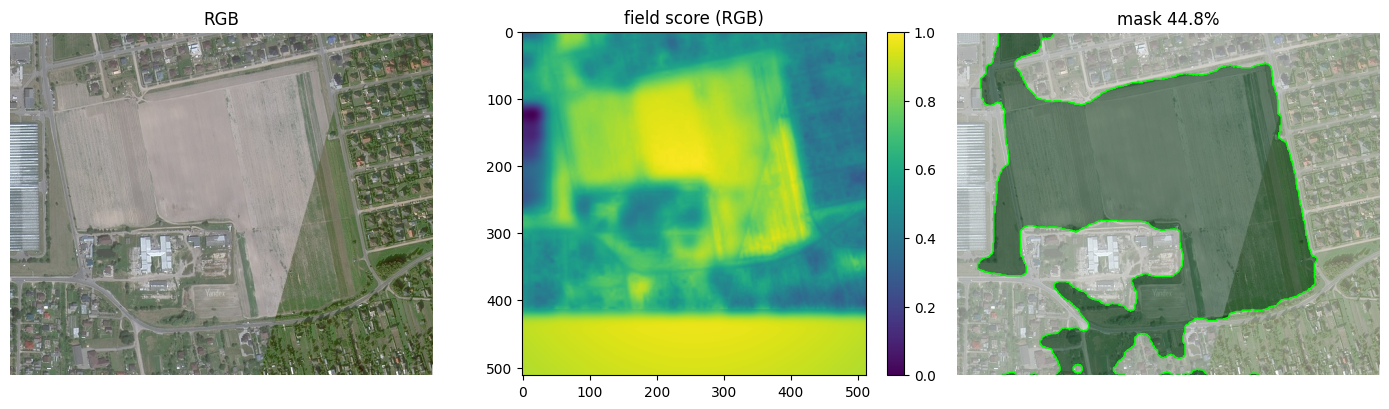

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].imshow(rgb_vis); ax[0].set_title('RGB'); ax[0].axis('off')
heat = score_vis if info.get('mode') == 'saturated_fallback' else prob_vis
htitle = 'field score (RGB)' if info.get('mode') == 'saturated_fallback' else f'P(field) th={th:.2f}'
im = ax[1].imshow(heat, cmap='viridis', vmin=0, vmax=1)
ax[1].set_title(htitle); plt.colorbar(im, ax=ax[1], fraction=0.046)
ax[2].imshow(rgb_vis)
ax[2].imshow(mask, cmap='Greens', alpha=0.4)
ax[2].contour(mask, levels=[0.5], colors='lime', linewidths=1)
ax[2].set_title(f'mask {mask.mean():.1%}'); ax[2].axis('off')
plt.tight_layout(); plt.show()


## 5. Полигоны

In [8]:
nav = mask_to_navigable_polygon(mask, headland_margin_px=12)
polys = mask_to_polygons(mask, min_area_px=300)
ORIGIN_LAT, ORIGIN_LON, M_PER_PX = 52.0, 23.7, 0.05
features = []
if nav['valid']:
    features.append(polygon_to_geojson_feature(nav['polygon_px'], ORIGIN_LAT, ORIGIN_LON, M_PER_PX))
out = ROOT / 'outputs' / 'inference'
out.mkdir(parents=True, exist_ok=True)
(out / 'field_polygons.geojson').write_text(
    json.dumps({'type': 'FeatureCollection', 'features': features}, indent=2), encoding='utf-8')
cv2.imwrite(str(out / 'mask.png'), mask * 255)
print('navigable vertices:', len(nav['polygon_px']), 'contours:', len(polys))
print('Saved:', out)


TypeError: polygon_to_geojson_feature() takes 1 positional argument but 4 were given

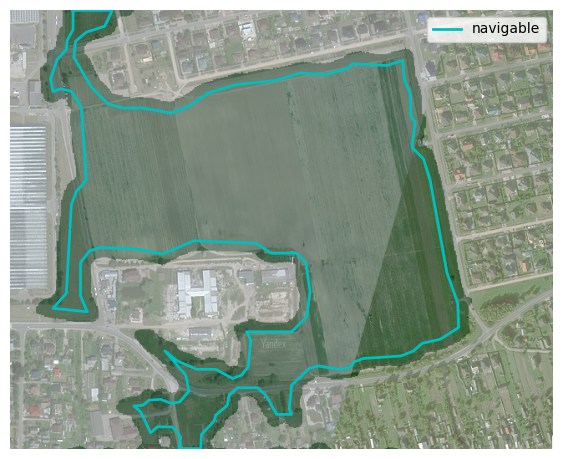

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
ax.imshow(rgb_vis)
ax.imshow(mask, cmap='Greens', alpha=0.3)
if nav['valid']:
    xs, ys = zip(*nav['polygon_px']); xs, ys = list(xs)+[xs[0]], list(ys)+[ys[0]]
    ax.plot(xs, ys, 'c-', lw=2, label='navigable')
ax.legend(); ax.axis('off'); plt.show()
